# CSE428 Assignment 2


In [ ]:
NAME = "Khan Md. Ziaus Samin"
ID = "22141011"
COLLABORATORS_ID = ""

This assignment contains 4 tasks. Complete the notebook with proper codes for the lines with `# TO-BE-COMPLETED` tag, or by *uncommenting* a partially written codes where necessary.

Background: We larned in class that linear spatial filtering is basically a signal correlation opration between an image and a filter kernel. To filter an ```image``` with a ```kernel``` all we need to do is call the ```signal.correlate``` function from the ```scipy``` library.

```
filtered_image = signal.correlate(image, kernel, mode='same', method='auto')
```
Here, ```mode="same"``` takes care of the image padding under the hood; making the filtered image the *same shape* as the input image, while ```mode="valid"``` *shrinks the filtered image*. The ```method='direct'``` implements the correlation from the definition of signal correlation:

> $g(x, y)=\sum_{s,t}{w(s, t)}f(x+s, y+t)$

whereas ```method='fft'``` uses a frequency domain implementation which we will learn next week. The ```method='auto'``` chooses the faster implementation automatically. <br>
(Except for **Task 1**, always use ```method='auto'``` while using the correlation function )




We use the following code stucture to measure the excecution time of some python code:

```
import time

start_time = time.clock()

# some python code

print("Time elapsed: ", time.clock() - start_time, "seconds")
```


## **Task 0: The Imports** <br>
### Import the necessary libraries and define the helper functions. You can use the helper functions from the coding tutorials, or you can even use your own version of helper functions. <br>


In [2]:
# Import libraries

import time
from skimage.io import imread
from skimage import img_as_float
from skimage.color import rgb2gray
from skimage.util import random_noise
import numpy as np
from numpy import pad
from scipy import signal
import matplotlib.pyplot as plt

In [3]:
# Define helper functions

def plot_image(img,figsize=(5,5)):
    plt.figure(figsize=figsize)
    if len(img.shape)==2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.axis("off")
    plt.show()
    print("Image shape: ", img.shape)

def plot_kernel(kernel, cmap="Reds"):
    plt.imshow(kernel, interpolation='none', cmap="Reds")
    plt.colorbar()
    plt.show()
    print("Kernel shape: ", kernel.shape)


def gaussian_kernel(width=1, size=10):
    x = np.linspace(-size // 2, size // 2, size)
    gaussian1dkernel = np.exp(-0.5 * (x / width)**2)
    gaussian1dkernel /= np.sum(gaussian1dkernel)
    kernel = np.outer(gaussian1dkernel, gaussian1dkernel)
    return kernel / np.sum(kernel)



## **Task 1: Execution Time** <br>
### Excecution time comparison for the 2 different methods of the correlation function <br>


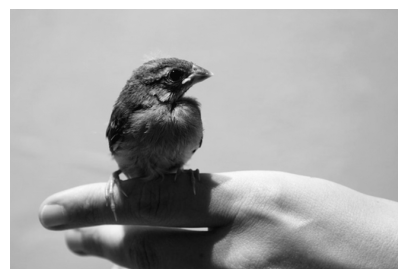

Image shape:  (342, 510)


In [7]:
# Import an image taken by you, make sure it's dimensions does not exceed (512, 512). Downsample if necessary.

image = img_as_float(imread("/Bird.png"))



if image.shape[-1] == 4:
	image = image[..., :3]

grayscale_image = rgb2gray(image)
plot_image(grayscale_image)




In [5]:
# Define a gaussian kernel of size (35, 35)

kernel = gaussian_kernel(35, 35)

In [ ]:
# Determine the time to filter the image with the kernel using "direct" method


start_time = time.perf_counter()





filetred_image_direct = signal.correlate(grayscale_image, gaussian_kernel(2, 21), mode='same', method='direct')





print("Time elapsed: ", time.perf_counter() - start_time, "seconds")

In [9]:
# Determine the time to filter the image with the kernel using "fft" method


start_time = time.perf_counter()





filetred_image_direct = signal.correlate(grayscale_image, gaussian_kernel(5, 50), mode='same', method='fft')





print("Time elapsed: ", time.perf_counter() - start_time, "seconds")

Time elapsed:  0.028764879999926052 seconds


### **Answer to Task 1** <br>

### Write your answer here. Comment on the results.

Result (answer): Takes forever to run direct method. Can't get time. Fft is much faster.

Comment (answer): Direct method is slower maybe. Fft is more efficient and faster maybe.

(From here onwards, please use ```method="auto"``` while using any signal function.)

## **Task 2: Correlation Vs. Convolution** <br>
### Comparing the correlation and convolution operation for different kernels<br>


In [43]:
# Import an image taken by you, make sure it's dimensions does not exceed (512, 512). Downsample if necessary.

image = img_as_float(imread("/Bird.png"))

if image.shape[-1] == 4:
	image = image[..., :3]

image = rgb2gray(image)


In [54]:
# Define any symmetric kernel of size (105, 105)

kernel_symmetric = gaussian_kernel(width=10, size=105)

In [55]:
# Define any asymmetric kernel of size (105, 105)

kernel_asymmetric = None # TO-BE-COMPLETED

In [56]:
# Filter the image with the symmetric kernel using the correlation function

filtered_image_symmetric = signal.correlate(image, kernel_symmetric, mode='same', method='auto')
#filtered_image_asymmetric = signal.correlate(image, kernel_asymmetric, mode='same', method='auto')

(np.float64(-0.5), np.float64(509.5), np.float64(341.5), np.float64(-0.5))

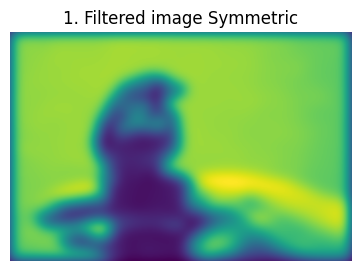

In [57]:
# Display the images side by side (with proper labeling, which is which)
#Multiple plots using pyplot
fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(2,3,1)
ax1.imshow(filtered_image_symmetric)
ax1.title.set_text('1. Filtered image Symmetric')
ax1.axis("off")

#ax2 = fig.add_subplot(2,3,2)
#ax2.imshow(filtered_image_asymmetric)
#ax2.title.set_text('2. Filtered image Assymmetric')
#ax2.axis("off")


### **Answer to Task 2.1** <br>

### Write your answer here. Compare the outputs.

Answer: The coorelated function seems to have given the image a lot of blur. Although I do not know why it changed color.
For the assymetric one it could be different.

Now, to *convolve* an ```image``` with a ```kernel``` all we need to do is call the ```signal.convolve``` function from the ```scipy``` library.

```
filtered_image = signal.convolve(image, kernel, mode='same', method='auto')```

The parameters work the same way as the ```signal.correlate```function.

(np.float64(-0.5), np.float64(509.5), np.float64(341.5), np.float64(-0.5))

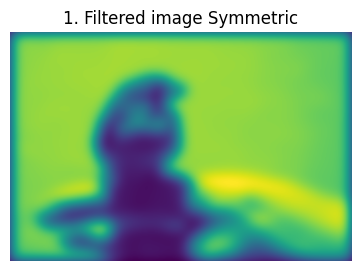

In [49]:
# Filter the image with the asymmetric kernel using the convolution function

filtered_image_symmetric = signal.convolve(image, kernel_symmetric, mode='same', method='auto')
filtered_image_asymmetric = None # TO-BE-COMPLETED

fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(2,3,1)
ax1.imshow(filtered_image_symmetric)
ax1.title.set_text('1. Filtered image Symmetric')
ax1.axis("off")


### **Answer to Task 2.2** <br>

### Write your answer here. Compare the outputs.
Answer: For the symmetric outputs I do not know any differences. The assymetric one's may have differences.

## **Task 3: Edge Pair Detector** <br>
### Try to come up with two 3 x 3 filter kernels which are able to detect ***only the parallel pair of edges*** in the following image<br>

![](https://drive.google.com/uc?export=view&id=1a1CXbuC8A2FbyFvZovJMXERUijpatecU)

[The image can be downloaded from here: https://drive.google.com/file/d/1a1CXbuC8A2FbyFvZovJMXERUijpatecU/view?usp=sharing]

*Hint: No mathematical derivation is necessary. Just try devising the kernels using the same intuitions used behind the horizontal and vertical edge detector kernels. Coming up with a filter kernel means to determine the 9 filter coefficients of the 3x3 filer kernel.*

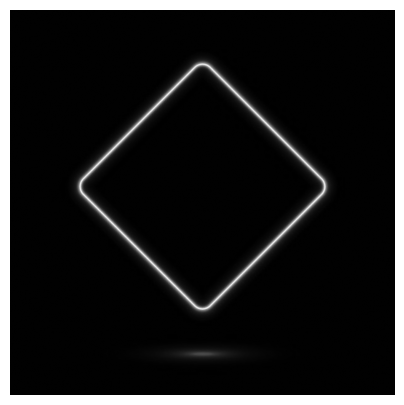

Image shape:  (626, 626)


In [65]:
# Download the image from the drive link above and upload it to your current working directory in colab. Then load the image

image = img_as_float(imread("/diamond2.jpg"))
image_gray = rgb2gray(image)  # Converts to 2D
image_gray = img_as_float(image_gray)
plot_image(image_gray)

In [69]:
# define the 2 custom kernels by replacing the "?"s with your values and uncomment the next few lines of code in this cell

kernel_1 = np.array([[-1, 0, 1], # TO-BE-COMPLETED
                      [-2, 0, 2], # TO-BE-COMPLETED
                      [-1, 0, 1]]) # TO-BE-COMPLETED

kernel_2 = np.array([[-1, -2, -1], # TO-BE-COMPLETED
                      [0, 0, 0], # TO-BE-COMPLETED
                      [1, 2, 1]]) # TO-BE-COMPLETED

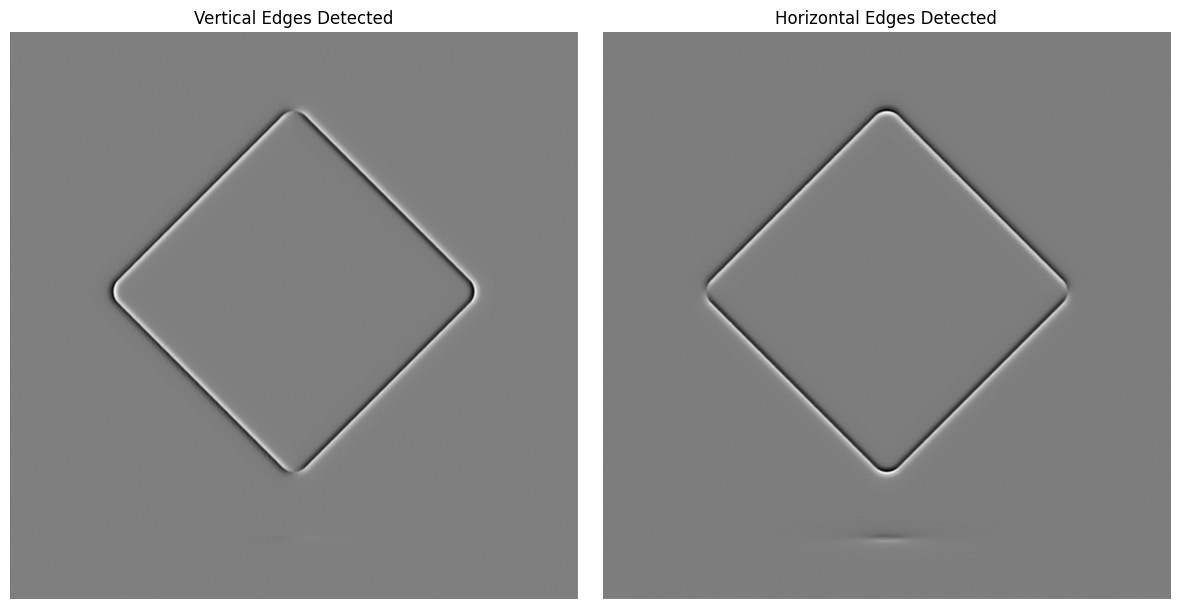

In [70]:
# detect the 2 parallel pair of edges and plot them side by side in a 1x2 grid subplot

# detect the first pair using image filtering with kernel_1

first_pair_detected = signal.convolve(image_gray, kernel_1, mode='same', method='auto')

# detect the second pair using image filtering with kernel_2

second_pair_detected = signal.convolve(image_gray, kernel_2, mode='same', method='auto')

# plot the two filtered images side by side

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(first_pair_detected, cmap='gray')
plt.title('Vertical Edges Detected')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(second_pair_detected, cmap='gray')
plt.title('Horizontal Edges Detected')
plt.axis('off')

plt.tight_layout()
plt.show()


### **Answer to Task 3** <br>

### Write your answer here. Which filters you came up with and why? How did you choose the coefficients? Are your kernels unique or there can be other kernels which can accomplish the same task?


Answer: I used the sobel operators as that compares the edges to the pixels on both sides. I used these as these compare the differences a bit more distinctly.

I chose these operators as they compre the pixels to their adjacents ones a bit more disctinctly whether they be vertical or horizontal.

The kernels are not unique as there are other one's that can do the same task like the Prewitt operators.

## **The END**